# Géométrie TF-IDF / LSA

Ici on transforme les documents en vecteurs TF-IDF, puis on réduit avec SVD.

But : voir si la géométrie sépare Statements/Minutes, périodes de crise, ou vocabulaire inflation/labor.

In [13]:
import os
import re
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomc_nlp_matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)

In [14]:
ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "fomc_documents_raw.csv").exists():
    ROOT = ROOT.parent

raw = pd.read_csv(ROOT / "data" / "raw" / "fomc_documents_raw.csv", parse_dates=["date"])

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?", re.IGNORECASE)


def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace(" ", " ")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def count_words(text):
    return len(TOKEN_RE.findall(clean_text(text)))


RATE_PATTERNS = {
    "hike": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(raise|raising|increase|increasing)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(raise|raising|increase|increasing|increased)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "cut": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "hold": [
        r"\b(decided|voted|agreed)\b.{0,80}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(will|would|shall|to)\b.{0,20}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(maintain|maintaining|keep|keeping|kept|leave|leaving)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(target range|target for the federal funds rate|federal funds rate)\b.{0,80}\b(unchanged|maintained)\b",
    ],
}


def infer_rate_decision(text):
    text = clean_text(text)
    for label in ["hike", "cut", "hold"]:
        if any(re.search(pattern, text, flags=re.DOTALL) for pattern in RATE_PATTERNS[label]):
            return label
    return "unknown"


df = (
    raw.sort_values("date")
    .reset_index(drop=True)
    .assign(
        statement_clean_text=lambda x: x["statement_text"].map(clean_text),
        minutes_clean_text=lambda x: x["minutes_text"].map(clean_text),
        statement_n_words=lambda x: x["statement_text"].map(count_words),
        minutes_n_words=lambda x: x["minutes_text"].map(count_words),
        rate_decision=lambda x: x["statement_text"].map(infer_rate_decision),
    )
    .assign(next_rate_decision=lambda x: x["rate_decision"].shift(-1))
)

df[["date", "statement_n_words", "minutes_n_words", "rate_decision", "next_rate_decision"]].head()

,date,statement_n_words,minutes_n_words,rate_decision,next_rate_decision
0,2000-02-02,202,8319,hike,hike
1,2000-03-21,208,4434,hike,hike
2,2000-05-16,202,4072,hike,hold
3,2000-06-28,178,4345,hold,hold
4,2000-08-22,181,4208,hold,hold


On reprend les scores inflation/labor pour colorer les points.

In [15]:
INFLATION_TERMS = [
    "inflation", "inflationary", "prices", "price stability", "price pressures",
    "inflation expectations", "core inflation", "pce inflation", "consumer prices",
    "energy prices", "food prices", "disinflation",
]

LABOR_TERMS = [
    "employment", "unemployment", "labor market", "job gains", "payrolls",
    "hiring", "layoffs", "wages", "labor demand", "labor supply",
    "labor force", "slack",
]


def count_terms(text, terms):
    text = clean_text(text)
    total = 0
    for term in terms:
        pattern = re.escape(term.lower()).replace(r"\ ", r"\s+")
        total += len(re.findall(rf"\b{pattern}\b", text))
    return total


def add_topic_score(data, corpus, topic, terms):
    text_col = f"{corpus}_clean_text"
    n_col = f"{corpus}_n_words"
    count_col = f"{corpus}_{topic}_count"
    freq_col = f"{corpus}_{topic}_per_1000"
    counts = data[text_col].map(lambda text: count_terms(text, terms))
    return data.assign(**{
        count_col: counts,
        freq_col: lambda x: 1_000 * x[count_col] / x[n_col].replace(0, np.nan),
    })


def period_label(date):
    date = pd.Timestamp(date)
    if pd.Timestamp("2001-03-01") <= date <= pd.Timestamp("2001-11-30"):
        return "2001 recession"
    if pd.Timestamp("2007-12-01") <= date <= pd.Timestamp("2009-06-30"):
        return "GFC"
    if pd.Timestamp("2020-02-01") <= date <= pd.Timestamp("2020-06-30"):
        return "Covid shock"
    if pd.Timestamp("2021-01-01") <= date <= pd.Timestamp("2024-12-31"):
        return "post-Covid inflation"
    return "other"


df = (
    df.pipe(add_topic_score, "statement", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "statement", "labor", LABOR_TERMS)
    .pipe(add_topic_score, "minutes", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "minutes", "labor", LABOR_TERMS)
    .assign(period=lambda x: x["date"].map(period_label))
)

df.head(2)

,date,year,meeting_id,statement_url,minutes_url,statement_text,minutes_text,statement_download_error,minutes_download_error,statement_clean_text,minutes_clean_text,statement_n_words,minutes_n_words,rate_decision,next_rate_decision,statement_inflation_count,statement_inflation_per_1000,statement_labor_count,statement_labor_per_1000,minutes_inflation_count,minutes_inflation_per_1000,minutes_labor_count,minutes_labor_per_1000,period
0,2000-02-02,2000,2000-02-02,https://www.federalreserve.gov/boarddocs/press/general/2000/20000202/,https://www.federalreserve.gov/fomc/minutes/20000202.htm,"Release Date: February 2, 2000 For immediate release The Federal Open Market Committee voted today to raise its target for the federal f...","Minutes of the Federal Open Market Committee February 1-2, 2000 A meeting of the Federal Open Market Committee was held in the offices o...",NaN,NaN,"release date: february 2, 2000 for immediate release the federal open market committee voted today to raise its target for the federal f...","minutes of the federal open market committee february 1-2, 2000 a meeting of the federal open market committee was held in the offices o...",202,8319,hike,hike,3,14.851485,0,0.0,80,9.61654,10,1.202068,other
1,2000-03-21,2000,2000-03-21,https://www.federalreserve.gov/boarddocs/press/general/2000/20000321/,https://www.federalreserve.gov/fomc/minutes/20000321.htm,"Release Date: March 21, 2000 For immediate release The Federal Open Market Committee voted today to raise its target for the federal fun...","Minutes of the Federal Open Market Committee March 21, 2000 A meeting of the Federal Open Market Committee was held in the offices of th...",NaN,NaN,"release date: march 21, 2000 for immediate release the federal open market committee voted today to raise its target for the federal fun...","minutes of the federal open market committee march 21, 2000 a meeting of the federal open market committee was held in the offices of th...",208,4434,hike,hike,3,14.423077,0,0.0,53,11.95309,6,1.353180,other


In [16]:
statement_docs = (
    df.loc[:, [
        "date", "year", "period", "rate_decision", "statement_clean_text",
        "statement_inflation_per_1000", "statement_labor_per_1000",
    ]]
    .rename(columns={
        "statement_clean_text": "text",
        "statement_inflation_per_1000": "inflation_per_1000",
        "statement_labor_per_1000": "labor_per_1000",
    })
    .assign(document_type="statement")
)

minutes_docs = (
    df.loc[:, [
        "date", "year", "period", "rate_decision", "minutes_clean_text",
        "minutes_inflation_per_1000", "minutes_labor_per_1000",
    ]]
    .rename(columns={
        "minutes_clean_text": "text",
        "minutes_inflation_per_1000": "inflation_per_1000",
        "minutes_labor_per_1000": "labor_per_1000",
    })
    .assign(document_type="minutes")
)

docs = (
    pd.concat([statement_docs, minutes_docs], ignore_index=True)
    .assign(balance_per_1000=lambda x: x["inflation_per_1000"] - x["labor_per_1000"])
)

docs.head()

,date,year,period,rate_decision,text,inflation_per_1000,labor_per_1000,document_type,balance_per_1000
0,2000-02-02,2000,other,hike,"release date: february 2, 2000 for immediate release the federal open market committee voted today to raise its target for the federal f...",14.851485,0.0,statement,14.851485
1,2000-03-21,2000,other,hike,"release date: march 21, 2000 for immediate release the federal open market committee voted today to raise its target for the federal fun...",14.423077,0.0,statement,14.423077
2,2000-05-16,2000,other,hike,"release date: may 16, 2000 for immediate release the federal open market committee voted today to raise its target for the federal funds...",14.851485,0.0,statement,14.851485
3,2000-06-28,2000,other,hold,"release date: june 28, 2000 for immediate release the federal open market committee at its meeting today decided to maintain the existin...",22.471910,0.0,statement,22.471910
4,2000-08-22,2000,other,hold,"release date: august 22, 2000 for immediate release the federal open market committee at its meeting today decided to maintain the exist...",16.574586,0.0,statement,16.574586


SVD donne une représentation dense des documents. C'est la version simple de l'idée “embedding”, sans modèle externe.

In [17]:
FED_STOP_WORDS = sorted(ENGLISH_STOP_WORDS | {
    "accessibility", "action", "adriana", "alan", "april", "august", "barkin", "barr", "bernanke",
    "bies", "board", "button", "chair", "chairman", "committee", "cook", "date",
    "connected", "daly", "december", "discount", "donald", "download", "edward", "february",
    "ferguson", "federal", "fomc", "geithner", "gov", "governors", "gramlich", "greenspan", "home", "https", "immediate",
    "information", "janet", "jefferson", "jerome", "john", "jr", "kugler", "lock",
    "january", "july", "june", "kohn", "lisa", "louis", "main", "march", "mark", "market", "mary",
    "may", "meeting", "menu", "messrs", "michael", "monetary", "mr", "ms", "november",
    "october", "official", "olson", "open", "page", "philip", "policy", "powell", "press",
    "minneapolis", "raphael", "release", "reserve", "roger", "search", "secure", "september", "share", "states",
    "submit", "subscribe", "susan", "timothy", "today", "toggle", "united", "update", "website", "websites",
    "william", "yellen",
})

vectorizer = TfidfVectorizer(
    stop_words=FED_STOP_WORDS,
    token_pattern=r"(?u)\b[a-z][a-z]+\b",
    ngram_range=(1, 2),
    min_df=2,
    max_features=8_000,
)
X = vectorizer.fit_transform(docs["text"])

svd = TruncatedSVD(n_components=30, random_state=42)
Z = svd.fit_transform(X)
Z_norm = normalize(Z[:, :20])

svd_summary = pd.DataFrame({
    "component": np.arange(1, 31),
    "explained_variance": svd.explained_variance_ratio_,
    "cum_explained_variance": svd.explained_variance_ratio_.cumsum(),
})

svd_summary.head(10).round(3)

,component,explained_variance,cum_explained_variance
0,1,0.052,0.052
1,2,0.109,0.161
2,3,0.061,0.222
3,4,0.049,0.272
4,5,0.042,0.314
5,6,0.039,0.353
6,7,0.033,0.385
7,8,0.029,0.414
8,9,0.027,0.442
9,10,0.025,0.467


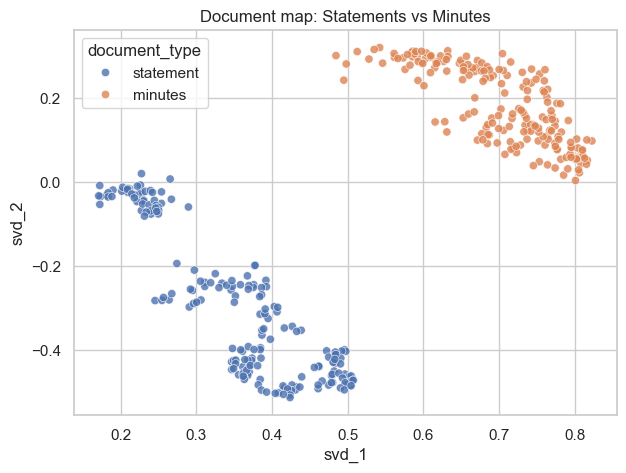

In [18]:
coords = docs.assign(
    svd_1=Z[:, 0],
    svd_2=Z[:, 1],
    svd_3=Z[:, 2],
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=coords, x="svd_1", y="svd_2", hue="document_type", alpha=0.8, ax=ax)
ax.set_title("Document map: Statements vs Minutes");

Si le premier plan sépare surtout Statements et Minutes, la géométrie capte d'abord le format du document.

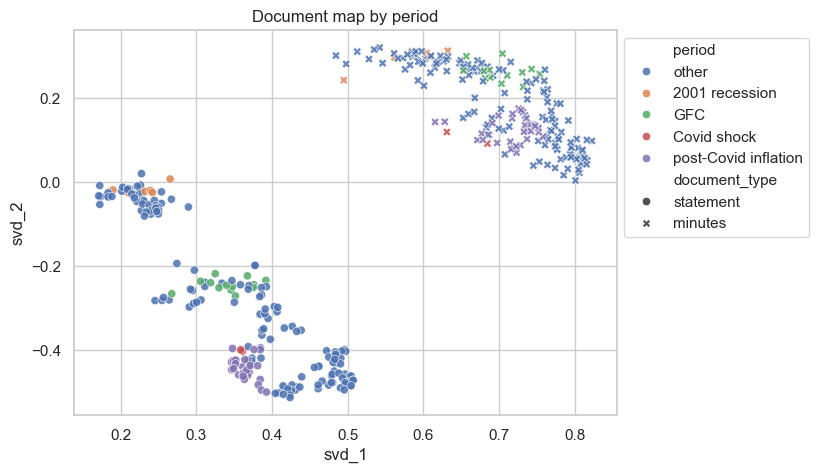

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=coords,
    x="svd_1",
    y="svd_2",
    hue="period",
    style="document_type",
    alpha=0.85,
    ax=ax,
)
ax.set_title("Document map by period")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1));

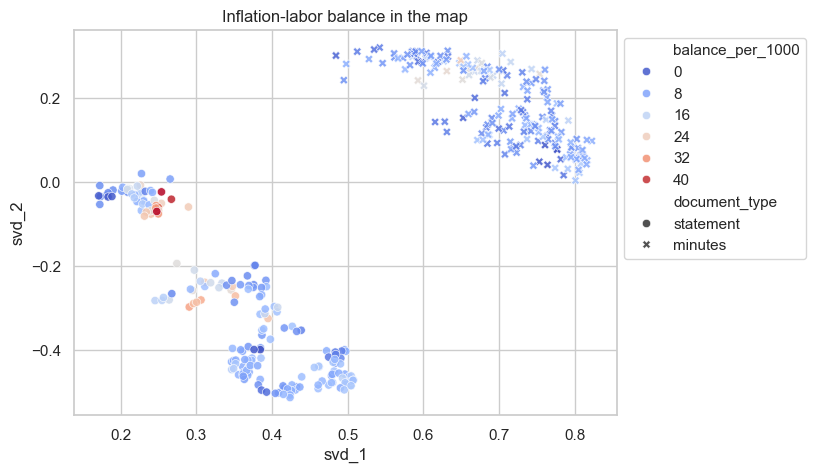

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=coords,
    x="svd_1",
    y="svd_2",
    hue="balance_per_1000",
    style="document_type",
    palette="coolwarm",
    alpha=0.85,
    ax=ax,
)
ax.set_title("Inflation-labor balance in the map")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1));

Petit clustering sur les composantes SVD. Le but est juste de lire les groupes.

In [21]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
coords = coords.assign(cluster=kmeans.fit_predict(Z_norm))

cluster_profile = (
    coords.assign(is_minutes=lambda x: x["document_type"].eq("minutes"))
    .groupby("cluster")
    .agg(
        n=("date", "size"),
        share_minutes=("is_minutes", "mean"),
        balance=("balance_per_1000", "mean"),
        inflation=("inflation_per_1000", "mean"),
        labor=("labor_per_1000", "mean"),
    )
    .round(2)
)

cluster_profile

,n,share_minutes,balance,inflation,labor
cluster,,,,,
0,70,0.0,12.30,18.01,5.70
1,67,1.0,10.66,14.07,3.41
2,81,0.0,9.96,22.61,12.65
3,132,1.0,7.06,13.72,6.66
4,48,0.0,15.88,18.35,2.46


Les clusters séparent d'abord le format : certains groupes sont presque uniquement des Statements ou des Minutes.

In [22]:
pd.crosstab(coords["cluster"], coords["period"], normalize="index").round(2)

period,2001 recession,Covid shock,GFC,other,post-Covid inflation
cluster,,,,,
0,0.00,0.00,0.19,0.81,0.00
1,0.09,0.00,0.06,0.85,0.00
2,0.00,0.02,0.00,0.58,0.40
3,0.00,0.02,0.07,0.67,0.24
4,0.12,0.00,0.00,0.88,0.00


In [23]:
terms = vectorizer.get_feature_names_out()
cluster_terms = []

for cluster in sorted(coords["cluster"].unique()):
    mask = coords["cluster"].eq(cluster).to_numpy()
    weights = np.asarray(X[mask].mean(axis=0)).ravel()
    top_idx = weights.argsort()[::-1][:12]
    cluster_terms.append({
        "cluster": cluster,
        "top_terms": ", ".join(terms[i] for i in top_idx),
    })

pd.DataFrame(cluster_terms)

,cluster,top_terms
0,0,"inflation, economic, securities, rate, growth, use, releases statement, longer, government, financial, mandate, voting ben"
1,1,"members, growth, inflation, quarter, prices, economic, consumer, year, spending, foreign, period, business"
2,2,"inflation, percent, range, economic, rate, target range, labor, conditions, employment, maximum employment, maximum, funds rate"
3,3,"participants, inflation, rate, economic, period, remained, continued, bank, financial, quarter, division, prices"
4,4,"growth, believes, rate, economic, target funds, sustainable, foreseeable future, foreseeable, goals price, background long, currently av..."


Les termes de clusters restent lisibles : QE/recovery, labor/employment, business/consumer, inflation/prices.

Nearest neighbors: quels documents sont proches dans l'espace SVD ?

In [24]:
similarity = cosine_similarity(Z_norm)


def nearest_docs(date, document_type, n=6):
    date = pd.Timestamp(date)
    idx = coords.index[coords["date"].eq(date) & coords["document_type"].eq(document_type)][0]
    nearest_idx = np.argsort(similarity[idx])[::-1]
    nearest_idx = [i for i in nearest_idx if i != idx][:n]
    return (
        coords.iloc[nearest_idx]
        .loc[:, ["date", "document_type", "period", "rate_decision", "balance_per_1000", "cluster"]]
        .assign(query=f"{date.date()} {document_type}", similarity=similarity[idx, nearest_idx])
    )

examples = pd.concat([
    nearest_docs("2008-12-16", "statement"),
    nearest_docs("2020-04-29", "statement"),
    nearest_docs("2022-06-15", "minutes"),
], ignore_index=True)

examples.round({"balance_per_1000": 2, "similarity": 3})

,date,document_type,period,rate_decision,balance_per_1000,cluster,query,similarity
0,2009-01-28,statement,GFC,hold,6.25,0,2008-12-16 statement,0.903
1,2008-10-29,statement,GFC,cut,8.91,0,2008-12-16 statement,0.870
2,2009-03-18,statement,GFC,hold,5.16,0,2008-12-16 statement,0.841
3,2009-04-29,statement,GFC,hold,6.84,0,2008-12-16 statement,0.827
4,2007-09-18,statement,other,cut,12.02,0,2008-12-16 statement,0.818
5,2008-04-30,statement,GFC,cut,21.41,0,2008-12-16 statement,0.808
6,2020-06-10,statement,Covid shock,hold,8.32,2,2020-04-29 statement,0.999
7,2020-07-29,statement,other,hold,6.43,2,2020-04-29 statement,0.996
8,2020-09-16,statement,other,hold,12.53,2,2020-04-29 statement,0.909
9,2020-11-05,statement,other,hold,11.01,2,2020-04-29 statement,0.901


Les voisins proches sont cohérents : GFC avec GFC, Covid avec 2020, Minutes 2022 avec le cycle inflationniste de 2022.